# Supplementary panel - Properties of ripples NATIM

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean/code')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import pywt
from scipy.stats import gaussian_kde
from matplotlib.colors import Normalize
from matplotlib import colormaps
from matplotlib.colors import TwoSlopeNorm

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

## Parameters

In [4]:
with open("/CSNG/studekat/ripple_paper_clean/code/params_analysis.yml") as f:
    params_analysis = yaml.safe_load(f)

DATA_FOLDER = params_analysis['data_folder'] ### folder with all the preprocessed data
DATES = params_analysis['dates']

DF_FOLDER = '/CSNG/studekat/ripple_band_project/dataframes' ### here the resulting dataframes will be saved
MONKEY_LIST = ['N','F']
AREAS_MERGED = params_analysis['areas_merged']
FINAL_CLASSES = params_analysis['final_classes']
CLASS_COLORS = params_analysis['colors_class']
CLASS_NAMES = params_analysis['classes_names']
COLORS_MONKEYS = params_analysis['colors_monkeys']

AREA = 'V12'
DUAL_TH = [2.5,3.5]

In [5]:
L_coors =np.array([[1,1],[0,0],[0,1],[2,2],  # row, col, the first 4 arrays
           [1,2],[2,3],[1,3],[2,4],
           [1,7],[2,7],[3,7],[1,6],
           [2,6],[1,5],[2,5],[1,4]])

In [6]:
N_coors =np.array([[1,4],[2,3],[2,4],[1,5],  # row, col, the first 4 arrays
           [2,5],[1,6],[2,7],[1,7],
           [1,2],[1,3],[0,4],[0,3],
           [0,2],[1,1],[0,1],[0,0]])

In [7]:
F_coors = np.array([[1,9],[0,9],[1,8],[0,8],  # row, col, the first 4 arrays
           [1,7],[0,7],[1,6],[1,5],
           [0,0],[0,1],[1,1],[0,2],
           [1,2],[0,3],[0,4],[0,5]])

In [8]:
A_coors = np.array([[1,1],[0,0],[0,1],[2,2],  # row, col, the first 4 arrays
           [1,2],[2,3],[1,3],[2,4],
           [1,7],[2,7],[3,7],[1,6],
           [2,6],[1,5],[2,5],[1,4]])

In [9]:
arrays_coors = {'A':A_coors,
              'L':L_coors,
              'N':N_coors,
              'F':F_coors,}
n_rows_dict = {'A':4,
              'L':4,
              'N':3,
              'F':2,}
n_cols_dict = {'A':8,
              'L':8,
              'N':8,
              'F':10,}

## Data loading

In [10]:
# loading ripples detected with lowpass on 40 on envelope
df_r = load_ripples_df(MONKEY_LIST,dual_th=[2.5,3.5],area=AREA,condition='NATIM',params=params_analysis,
                       df_folder=DF_FOLDER,exclude_noisy=True,verbose=False)

In [11]:
df_pos_peak_trig = load_ripple_trig_df(MONKEY_LIST,dual_th=DUAL_TH,condition='NATIM',params = params_analysis,
                              df_folder=DF_FOLDER,trigg_option='signal_max_pos_peak')

N
20220111_B1
20220111_B2
20220111_B3
20220111_B4
20220111_B5
20220111_B6
20220111_B7
20220111_B8
20220111_B9
20220111_B10
20220112_B1
20220112_B2
20220112_B3
20220112_B4
20220112_B5
20220112_B6
20220112_B7
20220112_B8
20220112_B9
20220112_B10
20220112_B11
20220113_B1
20220113_B2
20220113_B3
20220113_B4
20220114_B1
20220114_B2
20220114_B3
F
20240112_B1
20240112_B2
20240112_B3
20240112_B4
20240115_B1
20240115_B2
20240115_B3
20240115_B4
20240115_B5
20240116_B1
20240116_B2
20240116_B3
20240116_B4
20240116_B5
20240118_B1
20240118_B2
20240118_B3


In [12]:
if AREA=='V12':
    df_pos_peak_trig_area = df_pos_peak_trig[df_pos_peak_trig['area'].isin(['V1','V2'])]
else:
    df_pos_peak_trig_area = df_pos_peak_trig[df_pos_peak_trig['area']==AREA]

## Functions

In [13]:
def calculate_ripple_rates_date_NATIM(monkey,dual_th=[2.5,3.5],params={},date='',
                              main_folder='/CSNG/studekat/ripple_band_project/',df_folder='',verbose=False):
    """
    Calculates ripple rates for each channel, pooling all monkeys in the list, all dates.
    Area can be chosen: V1, V2, V12, V4, IT.

    Returns a dict with lists of rates for channels in all Rec.
    """
    condition = 'RS'

    df_r = load_ripples_df(monkey,dual_th=dual_th,date=date,area=None,condition=condition,
                           params=params_analysis,df_folder=df_folder,exclude_noisy=True,verbose=verbose)  # only including good channels
    all_arr_dict = {}
    all_arrays = range(1,17)
    for array in all_arrays:
        ripple_rates_ch_list = []
        df_array = df_r[df_r['array']==array]

        if df_array.shape[0]>0:
            dur_rec_date_arr_ms = df_array.iloc[0]['stop_rec_ms'] - df_array.iloc[0]['start_rec_ms']  # might be slightly different for each array
            dur_rec_date_arr_s = dur_rec_date_arr_ms/1000
            for ch in range(64): #np.unique(df_array['channel_0_63']): 
                try:
                    df_ch = df_array[df_array['channel_0_63']==ch]
                    num_ripples_ch = df_ch.shape[0]
                    ripple_rates_ch_list.append(num_ripples_ch/dur_rec_date_arr_s)
                except:
                    ripple_rates_ch_list.append(0)
        else:
            if verbose:
                print(f'No data for monkey {monkey}, array {array}.')
            ripple_rates_ch_list = list(np.zeros(64))

        rates_dict = {'All': ripple_rates_ch_list,}
        all_arr_dict[array] = rates_dict
    return all_arr_dict

In [14]:
def calculate_ripple_rates_fig1_NATIM(monkey_list,dual_th=[2.5,3.5],area=None,params={},
                              main_folder='/CSNG/studekat/ripple_band_project/',df_folder='',verbose=False):
    """
    Calculates ripple rates for each channel, pooling all monkeys in the list, all dates.
    Area can be chosen: V1, V2, V12, V4, IT.

    Returns a dict with lists of rates for channels in all Rec.
    """
    condition = 'NATIM'
    
    ripple_rates_ch_list = []
    for monkey in monkey_list:
        all_dates = params['dates'][monkey][condition]
        for date in all_dates:
            df_r = load_ripples_df(monkey,dual_th=dual_th,date=date,area=area,condition=condition,
                                   params=params_analysis,df_folder=df_folder,exclude_noisy=True,verbose=verbose)  # only including good channels
            if area is not None:
                if area in ['V4','IT','V1','V2']:
                    all_arrays = np.where(np.array(params['areas'][monkey])==area)[0] + 1  # shifting indexing from 0 to 1
                if area in ['V12']:
                    all_arrays = np.where(np.isin(np.array(params['areas'][monkey]),['V1','V2']))[0] + 1 
            else:
                all_arrays = range(1,17)
            for array in all_arrays:
                df_array = df_r[df_r['array']==array]
                if df_array.shape[0]>0:
                    dur_rec_date_arr_ms = df_array.iloc[0]['stop_rec_ms'] - df_array.iloc[0]['start_rec_ms']  # might be slightly different for each array
                    dur_rec_date_arr_s = dur_rec_date_arr_ms/1000
                    for ch in np.unique(df_array['channel_0_63']): 
                        df_ch = df_array[df_array['channel_0_63']==ch]
                        num_ripples_ch = df_ch.shape[0]
                        df_ch = df_ch[df_ch['eyes_closed'].notna()]  # not using non-classified times of recording
                        ripple_rates_ch_list.append(num_ripples_ch/dur_rec_date_arr_s)
                else:
                    if verbose:
                        print(f'No data for monkey {monkey}, array {array}.')

    rates_dict = {'All': ripple_rates_ch_list,}
    return rates_dict

In [15]:
def calculate_ripple_prop_fig1_NATIM(monkey_list,dual_th = [2.5,3.5],prop='duration_ms',area=None,params={},
                              main_folder='/CSNG/studekat/ripple_band_project/',df_folder='',verbose=False):
    """
    Calculates ripple prop. as chosen, pooling all monkeys in the list, all dates.
    Area can be chosen.

    prop: duration_ms, amplitude, freq, CV ICI

    Returns a dict with lists of the values of a given prop. for channels in all Rec, EC, and EO.
    """
    condition = 'NATIM'
    
    ripple_prop_list = []
    for monkey in monkey_list:
        all_dates = params['dates'][monkey][condition]
        for date in all_dates:
            df_r = load_ripples_df(monkey,dual_th=dual_th,date=date,area=area,condition=condition,
                                   params=params_analysis,df_folder=df_folder,exclude_noisy=True)  # only including good channels
            if area is not None:
                if area in ['V4','IT','V1','V2']:
                    all_arrays = np.where(np.array(params['areas'][monkey])==area)[0] + 1  # shifting indexing from 0 to 1
                if area in ['V12']:
                    all_arrays = np.where(np.isin(np.array(params['areas'][monkey]),['V1','V2']))[0] + 1 
            else:
                all_arrays = range(1,17)
            for array in all_arrays:
                df_array = df_r[df_r['array']==array]
                if df_array.shape[0]>0:
                    ripple_prop_list.append(df_array[prop].values)
                else:
                    if verbose:
                        print(f'No data for monkey {monkey}, array {array}.')

    prop_dict = {'All': list_merge(ripple_prop_list),}
    return prop_dict

In [17]:
def plot_ripple_start_trigg(df_ripple_start_trig,type_sig='LFP',set_params={}):
    """
    PANEL 1
    
    Average ripple triggered LFP/RB (LFP, RB_sig type_sig).
    """
    fig, ax = plt.subplots(dpi=200)
    fig.set_figwidth(set_params['plot_width'])
    fig.set_figheight(set_params['plot_height'])

    plt.suptitle(f'RB trig. LFP')

    column_name = f'{type_sig}_trigg_mean'
    #print(column_name)
    valid_rows = df_ripple_start_trig[column_name].apply(lambda x: isinstance(x, np.ndarray) and x.shape==(20000,))
    filtered_values = df_ripple_start_trig.loc[valid_rows, column_name].to_numpy()

    RB_sig_mean = np.nanmean(np.vstack(filtered_values),axis=0)
    buffer = set_params['buffer']

    color_option = 'gray'
    
    x = np.arange(-buffer,buffer)
    
    ax.plot(x,RB_sig_mean[10000-buffer:10000+buffer],color=color_option) #,label=labels[option])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Time [ms]')

    ax.set_ylabel(f'Avg. {type_sig} [norm. u.]')
    ax.axvline(0,ls='dashed',color='gray',alpha=0.7)

    fig.legend(loc='upper right', bbox_to_anchor=(1.1, 1))
    plt.show()
    plt.close()
    return 

In [18]:
def plot_ripple_stats(data_dict,set_params={}):
    """
    Plotting statistics for ripples.
    """
    fig, ax = plt.subplots(dpi=200)
    fig.set_figwidth(set_params['plot_width'])
    fig.set_figheight(set_params['plot_height'])
    
    if 'title' in set_params.keys():
        ax.set_title(set_params['title'])

    palette = set_params['colors_monkeys']

    position = 0
    for monkey in ['N','F']:
        df = pd.DataFrame([{"group": k, "value": v} for k, vals in data_dict.items() for v in vals])
        df = df[df['group']==monkey]
        sns.boxplot(x='group',y='value',data=df,ax=ax, positions=[position],
                 palette=set_params['colors_monkeys'],hue='group',showfliers=False,
                boxprops=dict(facecolor="none", edgecolor=set_params['colors_monkeys'][monkey], linewidth=1.5),
                                     medianprops=dict(color=set_params['colors_monkeys'][monkey], linewidth=1.5),width=0.5,
                                    whiskerprops=dict(color=set_params['colors_monkeys'][monkey], linewidth=1.5,visible=True),
                                    capprops=dict(color=set_params['colors_monkeys'][monkey], linewidth=1.5,visible=True))
        position+=1
    

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if 'y_label' in set_params.keys():
        ax.set_ylabel(set_params['y_label'])

    if 'x_label' in set_params.keys():
        ax.set_xlabel(set_params['x_label'])

    if 'ylim' in set_params.keys():
        ax.set_ylim(set_params['ylim'])  

    plt.show()
    plt.close()
    return

## Plotting

In [19]:
set_params = {}
set_params['plot_width'] = 2
set_params['plot_height'] = 2
set_params['colors_monkeys'] = COLORS_MONKEYS

### Ripple rate per channel

In [20]:
rates_dict_animals = {}
for monkey in MONKEY_LIST:
    rates_dict = calculate_ripple_rates_fig1_NATIM([monkey],dual_th = [2.5,3.5],area=AREA,params=params_analysis,
                                           main_folder='/CSNG/studekat/ripple_band_project/',df_folder=DF_FOLDER,verbose=False)
    rates_dict_animals[monkey] = rates_dict['All']

In [21]:
set_params['title'] = '' #'Ripple rate' #f'{MONKEY_LIST}, Ripple rate'
set_params['ylim'] = [-0.05,1.5]
set_params['y_label'] = 'Rate [/s on channel]'
set_params['x_label'] = 'Monkey'
#set_params['violin_bw'] = 0.2
#set_params['violin_alpha'] = 0.8

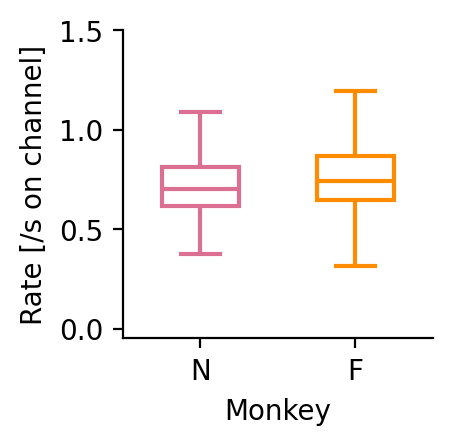

In [22]:
plot_ripple_stats(rates_dict_animals,set_params)

### Ripple duration

In [23]:
dur_dict_animals = {}
for monkey in MONKEY_LIST:
    duration_dict = calculate_ripple_prop_fig1_NATIM([monkey],prop='duration_ms',dual_th = [2.5,3.5],area=AREA,params=params_analysis,
                                       main_folder='/CSNG/studekat/ripple_band_project/',df_folder=DF_FOLDER,verbose=False)
    dur_dict_animals[monkey] = duration_dict['All']

In [24]:
set_params['title'] = '' #'Duration of ripples' #f'{MONKEY_LIST}, Duration of ripples '
set_params['ylim'] = [30,100]
set_params['y_label'] = 'Duration [ms]'
set_params['x_label'] = 'Monkey'
set_params['cut_data'] = 500  # maximal data point allowed in the stats
#set_params['violin_bw'] = 0.8
#set_params['violin_alpha'] = 0.8

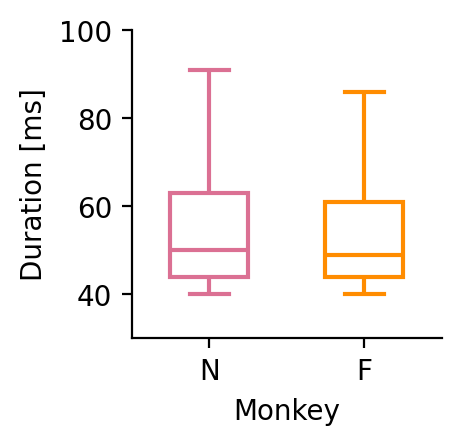

In [25]:
plot_ripple_stats(dur_dict_animals,set_params)

### Ripple amplitude

In [26]:
amp_dict_animals = {}
for monkey in MONKEY_LIST:
    amp_dict = calculate_ripple_prop_fig1_NATIM([monkey],prop='amplitude',dual_th = [2.5,3.5],area=AREA,params=params_analysis,
                                       main_folder='/CSNG/studekat/ripple_band_project/',df_folder=DF_FOLDER,verbose=False)
    amp_dict_animals[monkey] = amp_dict['All']

In [27]:
set_params['title'] = '' #'Amplitude of ripples' #f'{MONKEY_LIST}, Amplitude of ripples \n'
set_params['ylim'] = [2.5,10]
set_params['x_label'] = 'Monkey'
set_params['y_label'] = 'Amplitude \n[z-scored u.]'
set_params['violin_bw'] = 1.5
set_params['violin_alpha'] = 0.8

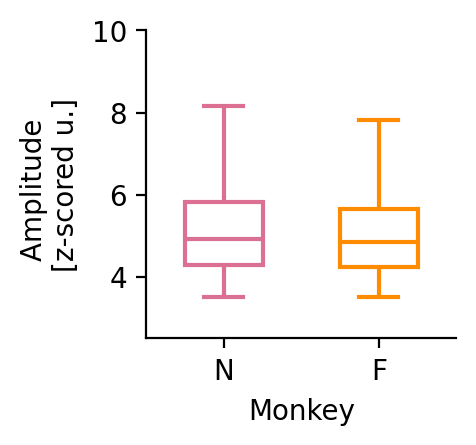

In [28]:
plot_ripple_stats(amp_dict_animals,set_params)

### Ripple frequency

In [34]:
freq_dict_animals = {}
for monkey in MONKEY_LIST:
    freq_dict = calculate_ripple_prop_fig1_NATIM([monkey],prop='freq',dual_th = [2.5,3.5],area=AREA,params=params_analysis,
                                       main_folder='/CSNG/studekat/ripple_band_project/',df_folder=DF_FOLDER,verbose=False)
    freq_dict_animals[monkey] = freq_dict['All']

In [35]:
set_params['title'] = '' #f'{MONKEY_LIST}, Frequency of ripples \n'
set_params['ylim'] = [70,150]
set_params['y_label'] = 'Frequency [Hz]'
set_params['x_label'] = 'Monkey'
set_params['violin_bw'] = 0.2
set_params['violin_alpha'] = 0.8

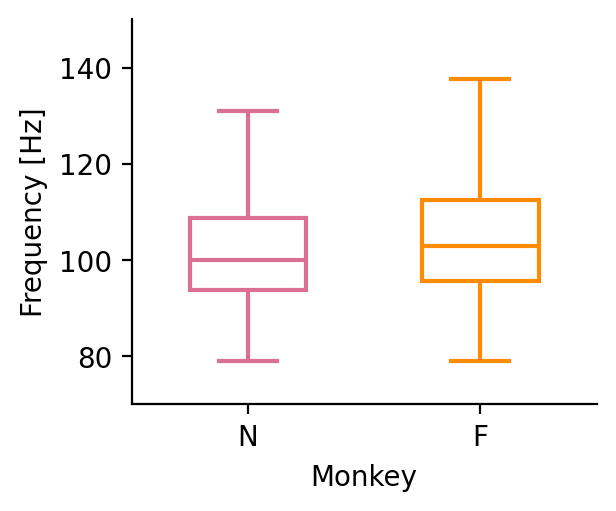

In [36]:
plot_ripple_stats(freq_dict_animals,set_params)

### Ripple peak triggered LFP

/tmp/ipykernel_343798/1093911350.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='upper right', bbox_to_anchor=(1.1, 1))


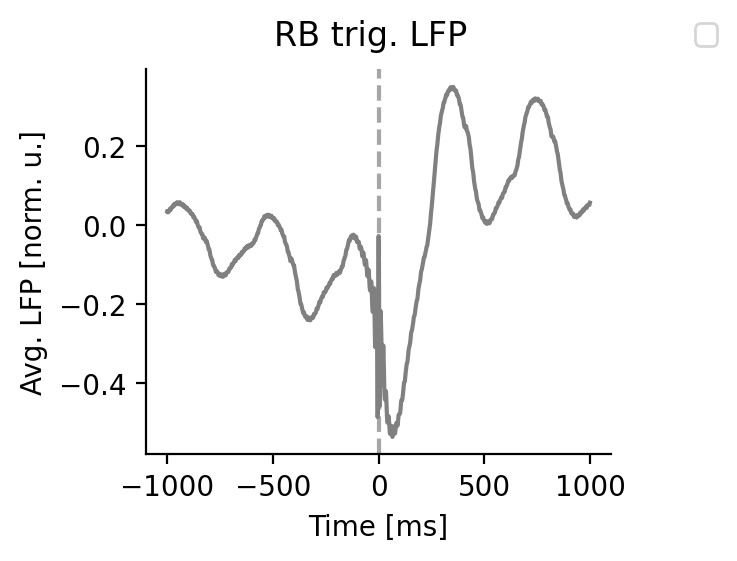

In [37]:
set_params['plot_width'] = 3
set_params['plot_height'] = 2.5
set_params['buffer'] = 1000
set_params['option'] = ''
plot_ripple_start_trigg(df_pos_peak_trig_area,'LFP',set_params=set_params)

/tmp/ipykernel_343798/1093911350.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='upper right', bbox_to_anchor=(1.1, 1))


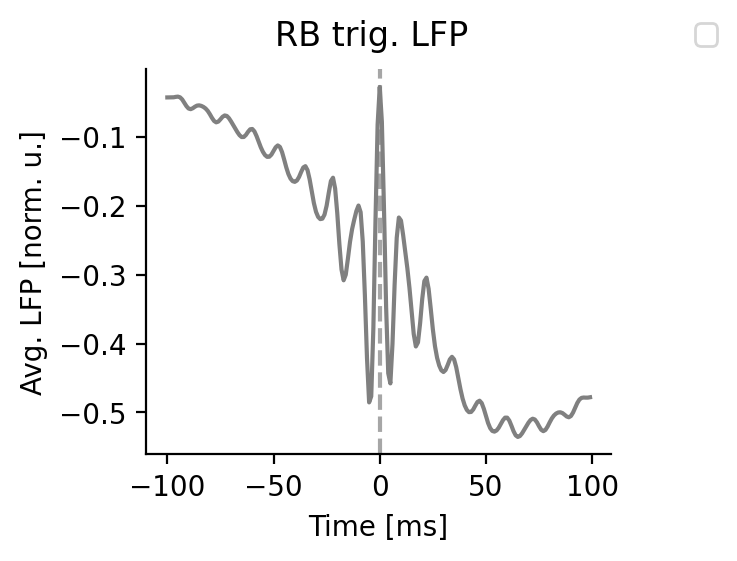

In [38]:
set_params['buffer'] = 100
plot_ripple_start_trigg(df_pos_peak_trig_area,'LFP',set_params)